In [11]:
import os
import sys
import random
from rdkit import Chem
from rdkit.Chem import BRICS
from rdkit.Chem import Draw
from rdkit.Chem import RDConfig

sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))

import sascorer

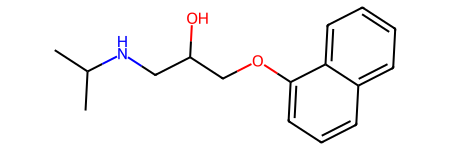

In [12]:
m = Chem.MolFromSmiles('CC(NCC(O)COC1=CC=CC2=CC=CC=C21)C')
m

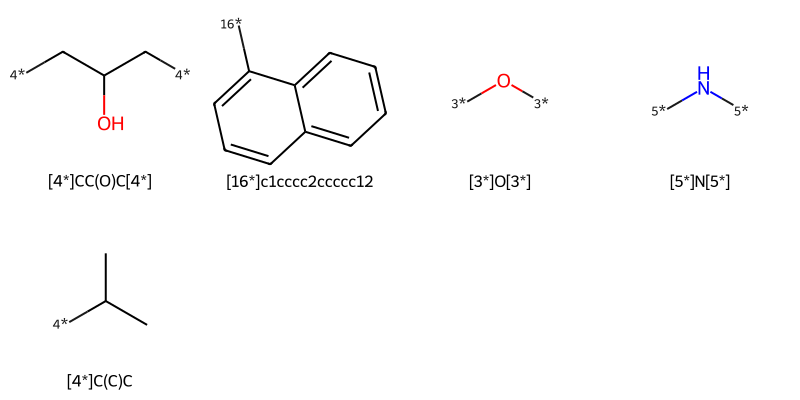

In [13]:
frags = list(Chem.BRICS.BRICSDecompose(m))
mols = [Chem.MolFromSmiles(f) for f in frags]
Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), legends=frags)

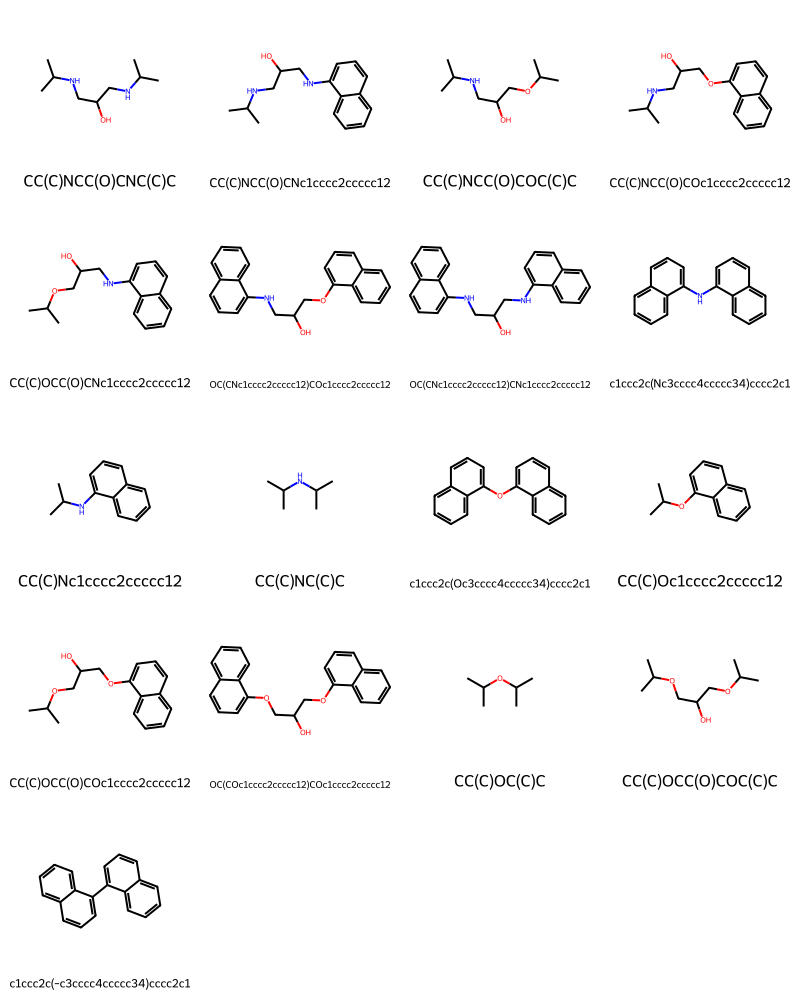

In [14]:
build = BRICS.BRICSBuild(mols)
random.seed(90)
prods = [next(build) for _ in range(17)]
Draw.MolsToGridImage(prods, molsPerRow=4, subImgSize=(200, 200),
                      legends=[Chem.MolToSmiles(p) for p in prods])

In [15]:
sa_scores = [sascorer.calculateScore(p) for p in prods]
Draw.MolsToGridImage(prods, molsPerRow=4, subImgSize=(200, 200),
                     legends=["%.2f"%s for s in sa_scores])

[11:20:58] DEPRECATION WARNING: please use MorganGenerator
[11:20:58] 

****
Pre-condition Violation
getNumImplicitHs() called without preceding call to calcImplicitValence()
Violation occurred on line 287 in file /home/conda/feedstock_root/build_artifacts/rdkit-meta_1722844818947/work/Code/GraphMol/Atom.cpp
Failed Expression: d_implicitValence > -1
----------
Stacktrace:
 0# Invar::Invariant::toString[abi:cxx11]() const in /vol/data/miniconda3/envs/graphbp_clone_rdkitconda/lib/python3.8/site-packages/rdkit/../../../libRDKitRDGeneral.so.1
 1# Invar::operator<<(std::ostream&, Invar::Invariant const&) in /vol/data/miniconda3/envs/graphbp_clone_rdkitconda/lib/python3.8/site-packages/rdkit/../../../libRDKitRDGeneral.so.1
 2# RDKit::Atom::getNumImplicitHs() const in /vol/data/miniconda3/envs/graphbp_clone_rdkitconda/lib/python3.8/site-packages/rdkit/Chem/../../../../libRDKitGraphMol.so.1
 3# RDKit::Atom::getTotalNumHs(bool) const in /vol/data/miniconda3/envs/graphbp_clone_rdkitconda/lib/pyt

RuntimeError: Pre-condition Violation
	getNumImplicitHs() called without preceding call to calcImplicitValence()
	Violation occurred on line 287 in file Code/GraphMol/Atom.cpp
	Failed Expression: d_implicitValence > -1
	RDKIT: 2024.03.5
	BOOST: 1_84


[11:14:23] DEPRECATION WARNING: please use MorganGenerator


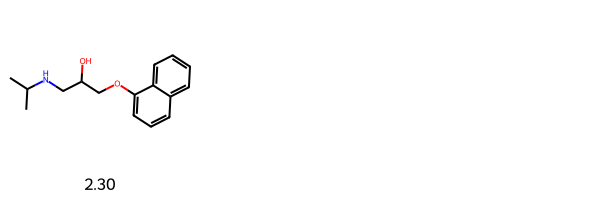

In [ ]:
Draw.MolsToGridImage([m], legends=["%.2f"%sascorer.calculateScore(m)])